In [158]:
import sys, os

project_root = '/Users/andrepfrommer/Desktop/neural_data_science_project'
sys.path.append(project_root)

poisson_gpfa_path = os.path.join(project_root, 'utils', 'poisson-gpfa')  # adjust as needed
sys.path.append(poisson_gpfa_path)

from utils.utils import *
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../poisson-gpfa/")
sys.path.append("../poisson-gpfa/funs")

import funs.util as util
import funs.engine as engine

## Ecker et al. (2014):

- *Noise correlations* express the amount of covariability in the trial-to-trial fluctuations of responses of two neurons to repeated presentations of the same stimulus
    - Central to understand the accuracy for neural population code
    - Can represent meaningful top-down signals generated internally in the brain (Cohen and Newsome, 2008)
    - Often, firing rate is insufficient to explain variability of correlations between studies
    - Tested one such top-down factor using in *anesthesia* which supresses firing rate  lasting few hundret milliseconds, slow wave oscillations

- Measured neurons in V1 of awake monkeys, where most were tuned to orientation, qualitatively similar between anasetezized and awake recordings
- anesthetized recordings appear noisier with larger fano factor (for our data this is not the case)
- Average level of correlations roughly sic times higher under anesthesia than during wakefulness

- If there a populations-level effect of the latent variable (anasthesia), where many neurons are modulated simulataneously on a trial-to-trial basis? 

- Utilize latent variable model called **Gaussian Process Factor Analysis (GPFA)**, which seeks to describe noise correlations in data by a low-dimensional state variable, evolving smoothly in time effecting each neurons $k$ firing rate linearly:


$$
y_k(t) = f_k(s(t)) + c_k x(t) + d_k \nu
$$

where $x(t)$ is the latent network state, which is here either one, two or threedimensional function of time. $c_k$ is the weight that determines how x affects the neurons response and $d_k$ a y intercept parameter. $\nu$ a gaussian noise. 

The network state $x$ has smooth autocorrelation function with timescale $\tau$ which is the covariance of the gaussian kernel which models the temporal correlations of the latent variable $x(t)$:
$$
K_{ij} = Cov[x(t_i), x(t_j)] = exp(- \frac{(t_i - t_j)^2}{2 \tau^2})
$$

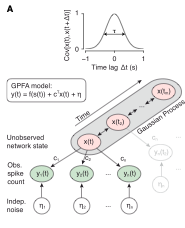

Advantages of using GPFA:
- Dont need to estimate full correlation matrix $O(N(N-1) / 2)$
- Supports the hyopthesis that during noise correlations, latent states affect many neurons at the same time

## Model fitting

- Extracted spike counts in each trial during a fixed stimulus period of $T = 30$ non-overlapping bins of size $33 ms$. 
- Also gathered running speed and its phase (still, running) during each trial
- Fitted model on the session of drifiting gratings, for each stimulus condition (orientation and temporal frequency of the grating) and running phase (still, running) independently to allow the weights to depend on the stimulus and to be able to discern between two phases of locomotion
    - Nr of EM iterations for each fit: 100
    - For each condition, fitting GPFA with latent state 1, 2, 3 dimensions
    - Cross validating with batch size 2 and nr of test trials=2
    - Each parameter was initialized based on Poisson-PCA init

In [159]:
data = load_saved_data("data_with_spikes_and_speed")

In [160]:
stim_table = data["sessions"]["A"]["stim_tables"]["drifting_gratings"]
print(f" Unique orientation: {stim_table['orientation'].unique()}")
print(f" Unique temporal frequencies: {stim_table['temporal_frequency'].unique()}")

 Unique orientation: [225. 180.  90. 270. 135. 315.   0.  45.  nan]
 Unique temporal frequencies: [ 1.  2.  4. 15.  8. nan]


In [161]:
# Set Hyperparameters
NR_TEST_TRIALS = 2
XDIM = 3
NR_EM_ITER = 100
BATCH_SIZE = 2
TEMPORAL_FREQUENCIES = [1, 2, 4, 8, 15]  # Hz
ORIENTATIONS = [0, 45, 90, 135, 180, 225, 270, 315]  # degrees
RUNNING_PHASES = [0, 1] # 0: still, 1: running 
NR_BINS = 30

In [162]:
class GPFADataset:
    """
    Create a GPFA-compatible dataset restricted to trials matching one or
    more stimulus conditions (parameter/value pairs), further restricted to
    time bins matching a given running phase.

    Every trial is truncated to exactly `minimum_nr_of_bins` qualifying bins,
    so all trials in the dataset have the same fixed length (self.T).
    Trials with fewer than `minimum_nr_of_bins` matching bins are dropped.
    """

    def __init__(
        self,
        data=None,
        session_id="B",
        stimulus="natural_scenes",
        parameters=["orientation", "temporal_frequency"],
        parameter_values=[0, 1],
        minimum_nr_of_bins=10,
        running_phase_value=None,  # 0 or 1; None = keep all bins regardless of phase
    ):
        session = data["sessions"][session_id]
        spikes = np.asarray(session["spikes"], dtype=float)
        t = np.asarray(session["t"], dtype=float)
        stim_table = session["stim_tables"][stimulus].copy()
        running_speed = np.asarray(session["running_speed_filtered"][0], dtype=float)
        running_phase = np.asarray(session["running_speed_phase"], dtype=int)

        for parameter, parameter_value in zip(parameters, parameter_values):
            stim_table = stim_table[stim_table[parameter] == parameter_value].reset_index(drop=True)

        dt_sec = float(np.median(np.diff(t)))
        dt_ms = dt_sec * 1000.0

        T = int(minimum_nr_of_bins)
        T -= T % 2  # keep even, as before
        if T < 1:
            raise ValueError("minimum_nr_of_bins must be >= 2 (kept even).")

        self.binSize = dt_ms
        self.ydim = spikes.shape[0]
        self.session_id = session_id
        self.stimulus = stimulus
        self.parameters = parameters
        self.parameter_values = parameter_values
        self.running_phase_value = running_phase_value
        self.T = T

        if stim_table.empty:
            self.data, self.trial_durs, self.trialDur, self.numTrials = [], [], 0, 0
            return

        max_start = min(spikes.shape[1], running_speed.shape[0], running_phase.shape[0])
        stim_metadata_cols = [c for c in stim_table.columns if c not in ("start", "end")]

        trials = []
        for _, row in stim_table.iterrows():
            start_idx = int(row["start"])
            stop_idx = int(row["end"])
            stop_idx = min(stop_idx, max_start)
            if stop_idx <= start_idx:
                continue

            Y = spikes[:, start_idx:stop_idx]
            speed = running_speed[start_idx:stop_idx]
            phase = running_phase[start_idx:stop_idx]

            if running_phase_value is not None:
                keep = phase == int(running_phase_value)
                if keep.sum() < T:
                    continue  # not enough matching bins in this trial
                Y = Y[:, keep]
                speed = speed[keep]
                phase = phase[keep]
            else:
                if Y.shape[1] < T:
                    continue  # trial too short even without phase filtering

            # Truncate every trial to exactly T bins, so all trials match in length.
            Y = Y[:, :T]
            speed = speed[:T]
            phase = phase[:T]

            trial_dict = {
                "Y": Y.copy(),
                "start_idx": start_idx,
                "end_idx": stop_idx,
                "running_speed": speed.copy(),
                "running_phase": phase.copy(),
            }
            trial_dict.update({col: row[col] for col in stim_metadata_cols})
            trials.append(trial_dict)

        if not trials:
            raise ValueError(
                f"No trials had at least {T} bins matching running_phase_value={running_phase_value}."
            )

        self.data = trials
        self.trial_durs = [T * dt_sec for _ in trials]
        self.trialDur = T * dt_ms
        self.numTrials = len(trials)

In [ ]:
# loop this over all possible temporal frequencies and orientations to create a dataset for each condition
fits = {}

for running_phase in RUNNING_PHASES:
    for orientation in ORIENTATIONS:
        for temporal_frequency in TEMPORAL_FREQUENCIES:
            
            data_drifting_gratings = GPFADataset(
                data=data,
                session_id="A",
                stimulus="drifting_gratings",
                parameters=["orientation", "temporal_frequency"],
                parameter_values=[orientation, temporal_frequency],
                minimum_nr_of_bins=NR_BINS,
                running_phase_value=running_phase,
            )
            
            if data_drifting_gratings.numTrials > NR_TEST_TRIALS:
                print(f"Orientation: {orientation}, Temporal Frequency: {temporal_frequency}, Running Phase: {running_phase}, Trials: {data_drifting_gratings.numTrials}, Trial Duration: {data_drifting_gratings.trialDur} ms, Bin Size: {data_drifting_gratings.binSize} ms")
                print(f"Fitting GPFA model for orientation {orientation}, temporal frequency {temporal_frequency}, and running phase {running_phase}...")
                
                xval_drifting_gratings = util.crossValidation(
                    experiment = data_drifting_gratings,
                    numTrainingTrials = data_drifting_gratings.numTrials - NR_TEST_TRIALS,
                    numTestTrials = NR_TEST_TRIALS,
                    maxXdim = XDIM,
                    maxEMiter = NR_EM_ITER, 
                    batchSize = BATCH_SIZE,
                    inferenceMethod = "laplace",
                    learningMethod = "batch",
                )

                train_set, test_set = util.splitTrainingTestDataset(
                    data_drifting_gratings, 
                    numTrainingTrials=data_drifting_gratings.numTrials - NR_TEST_TRIALS, 
                    numTestTrials=NR_TEST_TRIALS
                )
                
                fits[(orientation, temporal_frequency, running_phase)] = (train_set, test_set, xval_drifting_gratings)

In [164]:
print("Datasets created for all combinations of orientation and temporal frequency.")
for (orientation, temporal_frequency, running_phase), (train_set, test_set, xval_drifting_gratings) in fits.items():
    print(f"Orientation: {orientation}, Temporal Frequency: {temporal_frequency}, Running Phase: {running_phase},Train Trials: {train_set.numTrials}, Test Trials: {test_set.numTrials}, Trial Duration: {train_set.trialDur} ms, Bin Size: {train_set.binSize} ms")

Datasets created for all combinations of orientation and temporal frequency.
Orientation: 0, Temporal Frequency: 1, Running Phase: 0,Train Trials: 7, Test Trials: 2, Trial Duration: 996.09375 ms, Bin Size: 33.203125 ms
Orientation: 0, Temporal Frequency: 2, Running Phase: 0,Train Trials: 5, Test Trials: 2, Trial Duration: 996.09375 ms, Bin Size: 33.203125 ms
Orientation: 0, Temporal Frequency: 4, Running Phase: 0,Train Trials: 10, Test Trials: 2, Trial Duration: 996.09375 ms, Bin Size: 33.203125 ms
Orientation: 0, Temporal Frequency: 8, Running Phase: 0,Train Trials: 6, Test Trials: 2, Trial Duration: 996.09375 ms, Bin Size: 33.203125 ms
Orientation: 0, Temporal Frequency: 15, Running Phase: 0,Train Trials: 9, Test Trials: 2, Trial Duration: 996.09375 ms, Bin Size: 33.203125 ms
Orientation: 45, Temporal Frequency: 1, Running Phase: 0,Train Trials: 5, Test Trials: 2, Trial Duration: 996.09375 ms, Bin Size: 33.203125 ms
Orientation: 45, Temporal Frequency: 2, Running Phase: 0,Train Trial

## Test error for different latent dimensions 

In [165]:
def baseline_error(xval, dataset) -> float:
    baseline_error = 0.0
    
    # pick the first model
    fit = xval[0]
    ydim, xdim = np.shape(fit.optimParams["C"])
    for tr in range(dataset.numTrials):
        # loop over neurons (y dimension)
        for nrn in range(dataset.ydim):
            # predict y with X the identity matrix
            x_id = np.ones((xdim, dataset.T))
            y_pred = np.exp(
                fit.optimParams["C"][nrn].dot(x_id).T + fit.optimParams["d"][nrn]
            )
            #compute SSE
            baseline_error += np.dot(
                dataset.data[tr]["Y"][nrn] - y_pred, 
                dataset.data[tr]["Y"][nrn] - y_pred
            )
    
    return baseline_error

In [166]:
# loop over all datasets and compute baseline and test errors

errors_dict = {}
for (orientation, temporal_frequency, running_phase), (train_set, test_set, xval_drifting_gratings) in fits.items():
    print(f"Computing baseline and test errors for Orientation: {orientation}, Temporal Frequency: {temporal_frequency}, Running Phase: {running_phase}")
    
    # Compute baseline error
    base_error = baseline_error(xval_drifting_gratings.fits, test_set)
    
    # Compute test error using the fitted model
    errors = []
    for fit in xval_drifting_gratings.fits:
        predBatch, predErr = util.leaveOneOutPrediction(fit.optimParams, test_set)
        errors.append(predErr)
    
    errors_dict[(orientation, temporal_frequency, running_phase)] = {
        "baseline_error": base_error,
        "test_errors": errors
    }

Computing baseline and test errors for Orientation: 0, Temporal Frequency: 1, Running Phase: 0
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Computing baseline and test errors for Orientation: 0, Temporal Frequency: 2, Running Phase: 0
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Computing baseline and test errors for Orientation: 0, Temporal Frequency: 4, Running Phase: 0
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Computing baseline and test errors for Orientation: 0, Temporal Frequency: 8, Running Phase: 0
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Computing baseline and test errors for Orientation: 0, Temporal Frequency: 15, R

In [ ]:
def plot_baseline_and_test_errors(errors_dict, figsize_per_cell=(3, 2)):
    """
    Plot baseline and per-model test errors for all
    (orientation, temporal_frequency, running_phase) conditions.
    """
    keys = list(errors_dict.keys())
    orientations = sorted({k[0] for k in keys})
    temporal_frequencies = sorted({k[1] for k in keys})
    phase_colors = {0: "steelblue", 1: "crimson"}
    phase_labels = {0: "Still", 1: "Running"}

    fig, axes = plt.subplots(
        len(orientations), len(temporal_frequencies),
        figsize=(figsize_per_cell[0] * len(temporal_frequencies),
                 figsize_per_cell[1] * len(orientations)),
        sharex=True, squeeze=False,
    )

    for i, orientation in enumerate(orientations):
        for j, temporal_frequency in enumerate(temporal_frequencies):
            ax = axes[i, j]

            for running_phase, color in phase_colors.items():
                errors = errors_dict.get((orientation, temporal_frequency, running_phase))
                if errors is None:
                    continue

                baseline_error_value = np.asarray(errors["baseline_error"]).mean()
                test_errors_values = [np.asarray(e).mean() for e in errors["test_errors"]]
                xdims = range(1, len(test_errors_values) + 1)

                ax.plot(xdims, test_errors_values, marker="o", color=color,
                        label=f"{phase_labels[running_phase]} (test)")
                ax.axhline(baseline_error_value, color=color, linestyle="--",
                           alpha=0.7, label=f"{phase_labels[running_phase]} (baseline)")

            ax.set_title(f"Ori {orientation:g}, TF {temporal_frequency:g}", fontsize=9)

    for ax in axes[-1, :]:
        ax.set_xlabel("Latent Dimensionality (xdim)")
    for ax in axes[:, 0]:
        ax.set_ylabel("Error")

    # One shared legend, deduplicated (each phase's test/baseline appears once)
    handles, labels = [], []
    for ax in axes.flat:
        h, l = ax.get_legend_handles_labels()
        for hh, ll in zip(h, l):
            if ll not in labels:
                handles.append(hh)
                labels.append(ll)
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.03), fontsize=8)

    fig.tight_layout()
    return fig, axes

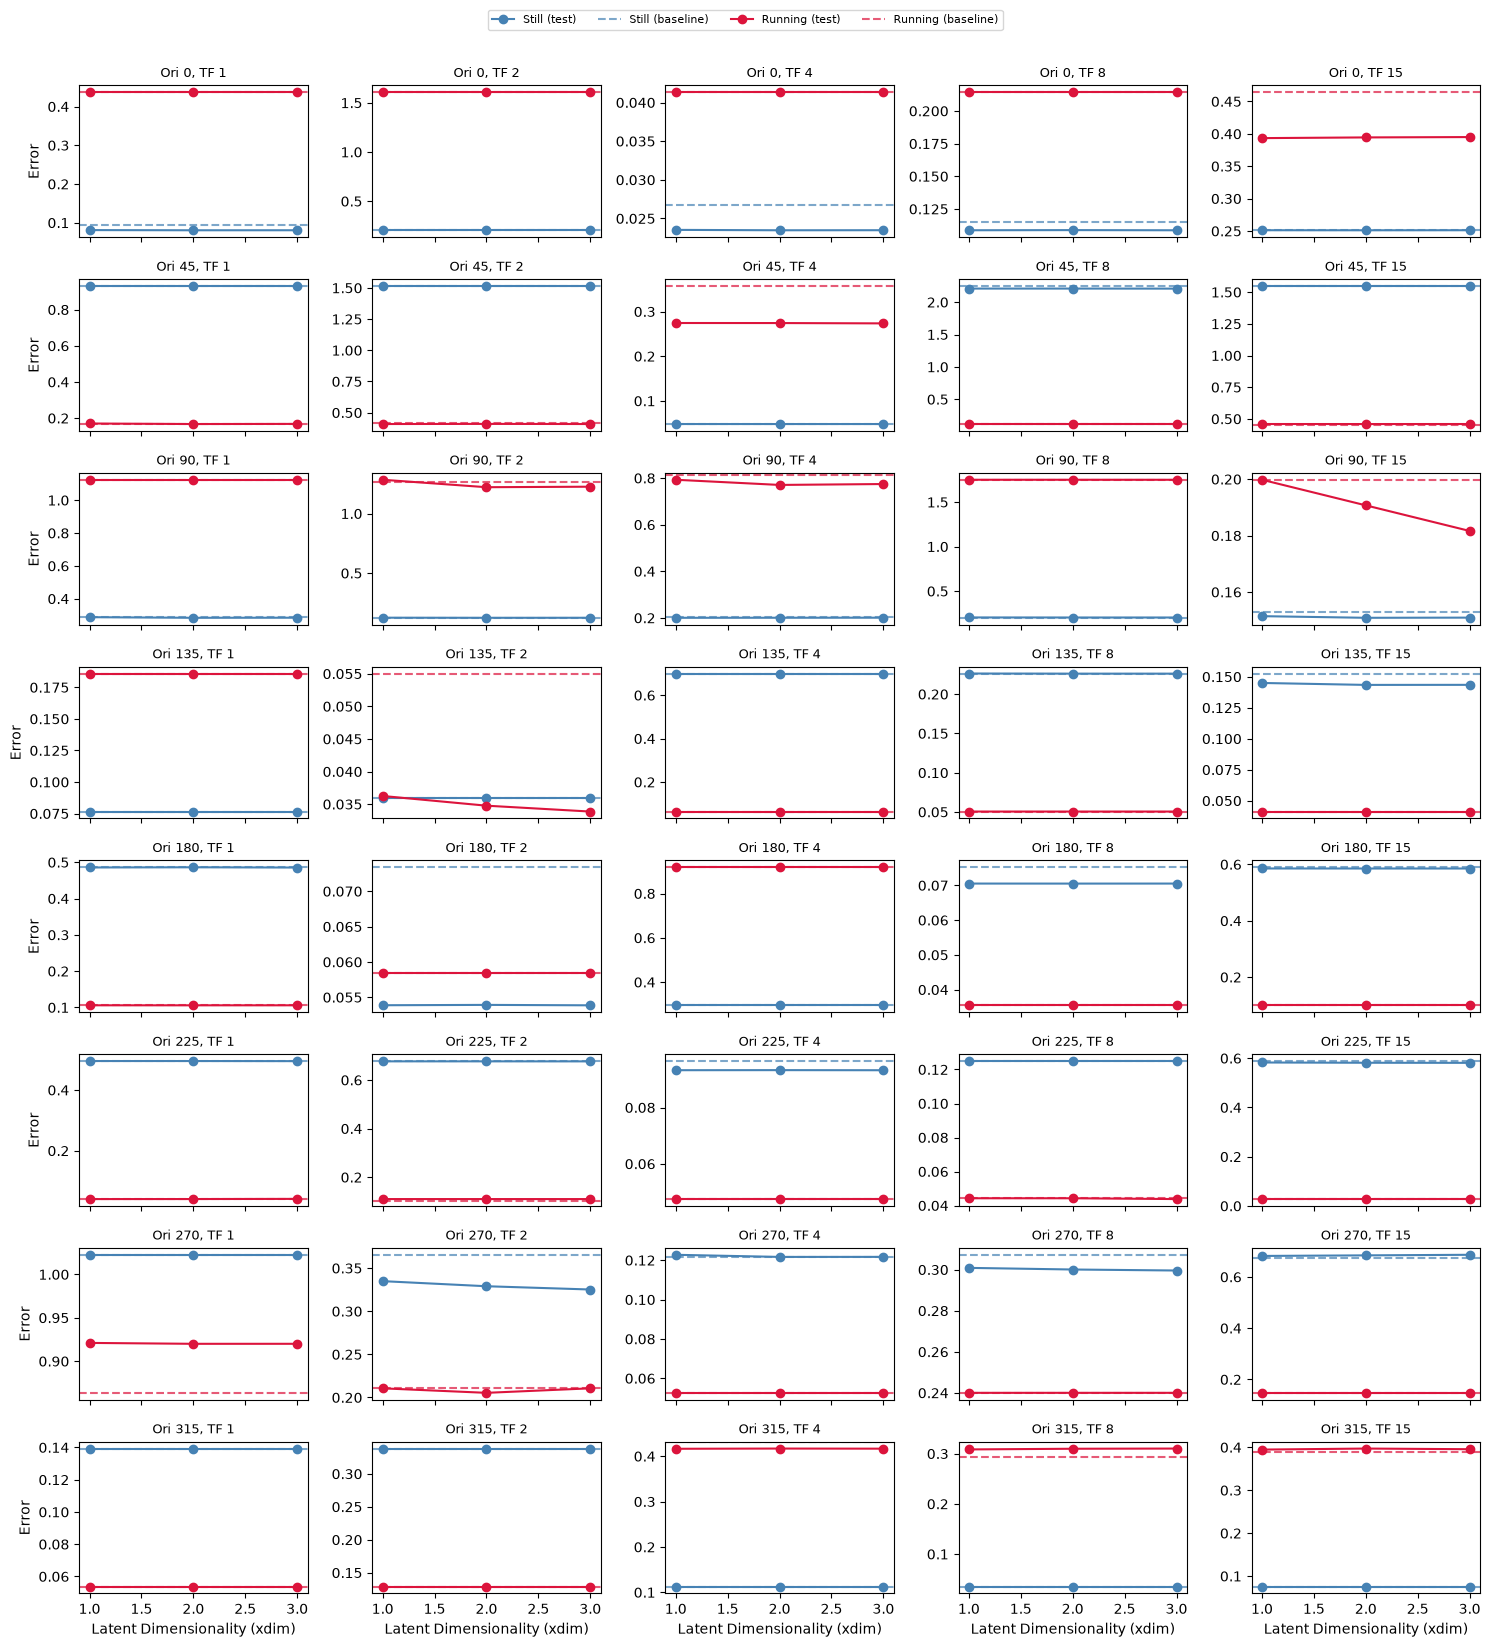

In [168]:
fig, axes = plot_baseline_and_test_errors(errors_dict)

TODO: Is this the right way to compute the baseline error?

## Noise correlations and their analytical approximations using GPFA parameters

The covariance approximation is given by 

$$
\text{Cov}= \mu\otimes\mu^T \odot \exp(CC^T)+\mu\cdot \mathbb{I} - \mu\otimes\mu^T
$$ 

In [ ]:
def compute_raw_cov(fits):
    raw_covariances = {}
    for (orientation, temporal_frequency, running_phase), (train_set, test_set, xval_drifting_gratings) in fits.items():
        print(f"Computing raw covariance for Orientation: {orientation}, Temporal Frequency: {temporal_frequency}, Running Phase: {running_phase}")
        
        all_Y = np.hstack([trial["Y"] for trial in train_set.data]) # shape (ydim, total_time_bins * num_trials)
        
        # Compute the covariance matrix
        raw_covariance = np.cov(all_Y) # shape (ydim, ydim)
        
        raw_covariances[(orientation, temporal_frequency, running_phase)] = raw_covariance
        
    return raw_covariances

In [ ]:
def compute_cov_approx(fits):
    """
    Compute the approximate covariance matrices for each fitted model in the
    cross-validation results.
    """
    cov_dict = {}
    for (orientation, temporal_frequency, running_phase), (train_set, test_set, xval_drifting_gratings) in fits.items():
        print(f"Computing approximate covariance for Orientation: {orientation}, Temporal Frequency: {temporal_frequency}, Running Phase: {running_phase}")

        approx_cov = []
        for fit in xval_drifting_gratings.fits:
            cov, _ = cov_anal(fit) # shape (ydim, ydim)
            approx_cov.append(cov)

        cov_dict[(orientation, temporal_frequency, running_phase)] = approx_cov

    return cov_dict

In [232]:
raw_covs = compute_raw_cov(fits)
approx_covs = compute_cov_approx(fits)

Computing raw covariance for Orientation: 0, Temporal Frequency: 1, Running Phase: 0
Computing raw covariance for Orientation: 0, Temporal Frequency: 2, Running Phase: 0
Computing raw covariance for Orientation: 0, Temporal Frequency: 4, Running Phase: 0
Computing raw covariance for Orientation: 0, Temporal Frequency: 8, Running Phase: 0
Computing raw covariance for Orientation: 0, Temporal Frequency: 15, Running Phase: 0
Computing raw covariance for Orientation: 45, Temporal Frequency: 1, Running Phase: 0
Computing raw covariance for Orientation: 45, Temporal Frequency: 2, Running Phase: 0
Computing raw covariance for Orientation: 45, Temporal Frequency: 4, Running Phase: 0
Computing raw covariance for Orientation: 45, Temporal Frequency: 8, Running Phase: 0
Computing raw covariance for Orientation: 45, Temporal Frequency: 15, Running Phase: 0
Computing raw covariance for Orientation: 90, Temporal Frequency: 1, Running Phase: 0
Computing raw covariance for Orientation: 90, Temporal Fr

In [244]:
def plot_covariances(raw_covs, approx_covs, orientation, temporal_frequency, running_phase):
    
    # get the raw and approximate covariances for the specified orientation and temporal frequency
    raw_cov = raw_covs.get((orientation, temporal_frequency, running_phase))
    approx_cov = approx_covs.get((orientation, temporal_frequency, running_phase))
    if raw_cov is None or approx_cov is None:
        raise KeyError(f"No covariance data found for orientation={orientation}, temporal_frequency={temporal_frequency}, running_phase={running_phase}")
    
    n_dims = len(approx_cov)
    fig, axes = plt.subplots(1, n_dims + 1, figsize=((n_dims + 1) * 3, 3))

    # Shared color scale across all panels so magnitudes are visually comparable.
    all_vals = [raw_cov] + list(approx_cov)
    vmax = max(np.abs(v).max() for v in all_vals)

    im0 = axes[0].imshow(raw_cov, cmap="magma", vmin=-vmax, vmax=vmax)
    axes[0].set_title("Raw Covariance")
    axes[0].set_xlabel("neuron")
    axes[0].set_ylabel("neuron")

    for i, cov in enumerate(approx_cov):
        im = axes[i + 1].imshow(cov, cmap="magma", vmin=-vmax, vmax=vmax)
        axes[i + 1].set_title(f"GPFA approx (dim={i + 1})")
        axes[i + 1].set_xlabel("neuron")
        axes[i + 1].set_ylabel("neuron")
        if i == n_dims - 1:
            fig.colorbar(im, ax=axes[i + 1], label="covariance")
            
    running_phase_str = "still" if running_phase == 0 else "running"
    fig.suptitle(f"Orientation {orientation:g}°, TF {temporal_frequency:g}, Movement {running_phase_str}", fontsize=16)
    fig.tight_layout()  # leave room for suptitle

    return fig, axes

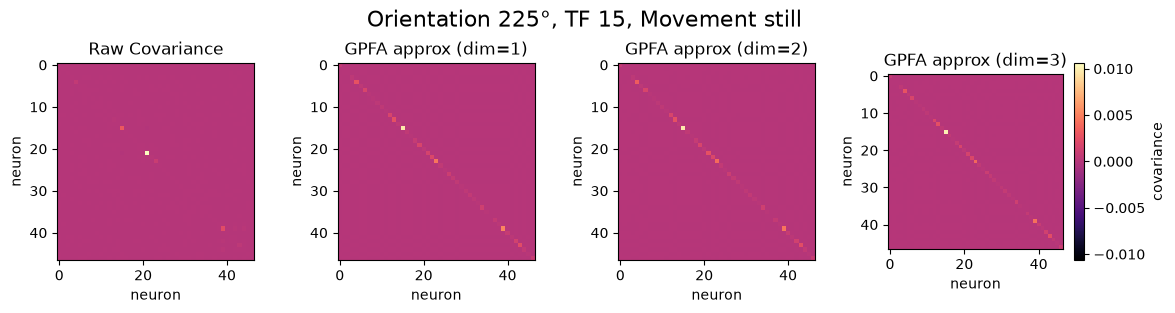

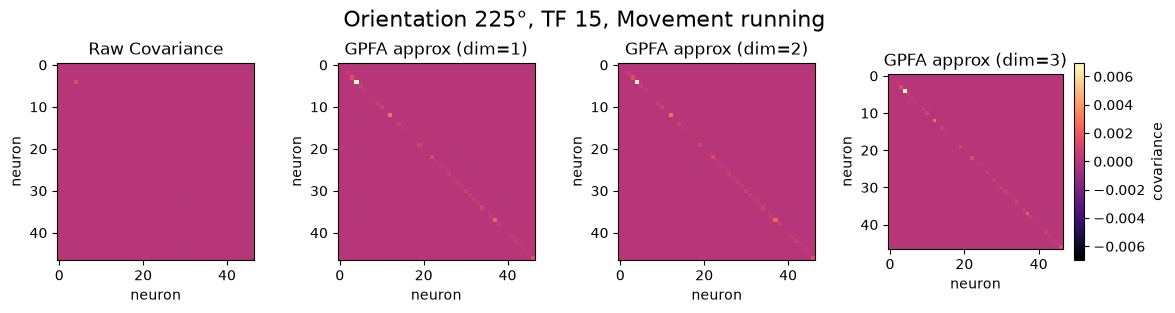

In [245]:
orientation_exp = 225
temporal_frequency_exp = 15
fig, ax = plot_covariances(raw_covs, approx_covs, orientation_exp, temporal_frequency_exp, 0)
plt.show()

fig, ax = plot_covariances(raw_covs, approx_covs, orientation_exp, temporal_frequency_exp, 1)
plt.show()

Looks like GPFA can at least reproduce the relative magnitude of the spike count for one neuron. We cannot, however, approximate correlations between neurons, like seen f.e for orientation: 30

This shows the pairwise covariance structure between all $45$ neuronsfor one example trial for two running phases. We selectedd this trial because in this trial the latent state in the running phase matches the running trace pretty good (see below).
- the raw covariance structure here suggests very low covariance structure in between trials, only the diagonal shows high values, which likely resemble neuron-intrinsic firing rates
- The model was able to explain this diagonal magnitude for both phases. However, as we dont (or only low) have correlations between neurons, we also see low values outside the diagonal for the model approximation

### GPFA Model parameter distributions

- Useful to gain insights into the structure of variability induced by the network state variable
- Weight distribution $c_k$ tells how much the latent state affects the firing rate of individual neurons
    - If cells are changed in one direction, we expect also the whole distribution to change into one direction during the phase when the latent state is active (here running)
    - however, here we find that for all stimulus conditions, the weights are distributed around zero, irrespective of the running phase

- Offset distribution $d_k$ accounts for the baseline firing rate of the individual neurons
    - We here see also see that distributions are similar for all stimulus conditions and running phases, although some outliers can be found
    - Interestingly, this corresponds to the neuron we found as being the one correlating most to running speed (neuron 25)

- Timescales $\tau$ of the latent state can be further used to constrain out hypothesis
    - For the gpfa to fit the running speed as latent state, the magnitude or $\tau$ should be of the same order 
    - We see timescales ranging from $0 - 0.6s$, again irrespective of the running phase 
    - Matches the timescale of the running speed only partly (note we clipped the frequencies at 5Hz). 
    - TODO: Plot power spectrum of the running traces!

In [199]:
def plot_param_histograms(
    fits,
    param_name="C",
    latent_dim=0,
    bins=30,
    neuron_idx=None,
    figsize_per_cell=(3, 2),
):
    """
    Plot histograms of the specified parameter (e.g., 'C' or 'd') across all
    (orientation, temporal_frequency) conditions, comparing running phases.

    One subplot per (orientation, temporal_frequency); within each subplot,
    running_phase=0 (still) is blue and running_phase=1 (running) is red,
    using the fit at `latent_dim` in each condition's xval.fits list.
    """
    keys = list(fits.keys())
    orientations = sorted({k[0] for k in keys})
    temporal_frequencies = sorted({k[1] for k in keys})
    phase_colors = {0: "steelblue", 1: "crimson"}
    phase_labels = {0: "Still", 1: "Running"}

    fig, axes = plt.subplots(
        len(orientations), len(temporal_frequencies),
        figsize=(figsize_per_cell[0] * len(temporal_frequencies),
                 figsize_per_cell[1] * len(orientations)),
    )

    for i, orientation in enumerate(orientations):
        for j, temporal_frequency in enumerate(temporal_frequencies):
            ax = axes[i, j]

            for running_phase, color in phase_colors.items():
                fit_data = fits.get((orientation, temporal_frequency, running_phase))

                train_set, test_set, xval = fit_data
                fit = xval.fits[latent_dim]

                params = fit.optimParams[param_name]
                param_values = params.flatten()

                ax.hist(param_values, bins=bins, color=color, alpha=0.5,
                        edgecolor="black", label=phase_labels[running_phase])
                
                if neuron_idx is not None and neuron_idx < params.shape[0]:
                    neuron_vals = np.atleast_1d(params[neuron_idx])
                    for val in neuron_vals:
                        ax.axvline(val, color=color, linestyle="--", linewidth=2, alpha=0.9, label=f"Neuron {neuron_idx}")
                    
            if i == 0 and j == 0:
                ax.legend(fontsize=8)
            ax.set_title(f"Orientation {orientation:g}°, TF {temporal_frequency:g} Hz", fontsize=9)
            ax.tick_params(axis="both", which="major", labelsize=6)

    xlabel = "time (s)" if param_name == "tau" else param_name
    for ax in axes[-1, :]:
        ax.set_xlabel(xlabel)
    for ax in axes[:, 0]:
        ax.set_ylabel("Frequency")


    fig.suptitle(f"Parameter '{param_name}' (latent_dim={latent_dim + 1})", fontsize=13, y=1.02)
    fig.tight_layout()
    return fig, axes

In [ ]:
def plot_tau_histogram(fits, latent_dim=0, bins=30):
    """
    Plot a histogram of the fitted GP timescale (tau) for a given latent
    dimension, pooled across all (orientation, temporal_frequency) conditions,
    split by running phase (0=still, blue; 1=running, red).
    """
    phase_colors = {0: "steelblue", 1: "crimson"}
    phase_labels = {0: "Still", 1: "Running"}
    taus_by_phase = {0: [], 1: []}

    for (orientation, temporal_frequency, running_phase), (train_set, test_set, xval) in fits.items():
        if running_phase not in taus_by_phase:
            continue  # unexpected phase value, skip

        for fit in xval.fits:
            params = fit.optimParams
            xdim = params["tau"].shape[0]
            if latent_dim >= xdim:
                continue  # this fit doesn't have that many latent dimensions

            tau = np.asarray(params["tau"]).flatten()[latent_dim]
            taus_by_phase[running_phase].append(tau)

    fig, ax = plt.subplots(figsize=(3, 2))
    for running_phase, color in phase_colors.items():
        taus = np.array(taus_by_phase[running_phase])
        if taus.size == 0:
            continue
        ax.hist(taus, bins=bins, color=color, alpha=0.5, edgecolor="black",
                label=f"{phase_labels[running_phase]} (n={len(taus)})")

    ax.set_xlabel("time constant (s)")
    ax.set_ylabel("count")
    ax.set_title(f"Latent dim {latent_dim}")
    ax.legend()
    fig.tight_layout()

    return fig, ax

(<Figure size 400x300 with 1 Axes>,
 <Axes: title={'center': 'Latent dim 0'}, xlabel='time constant (s)', ylabel='count'>)

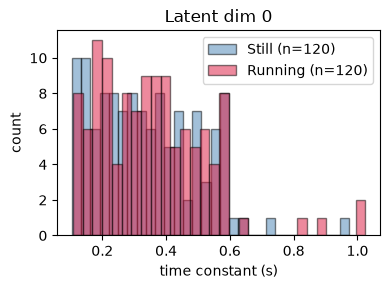

In [176]:
plot_tau_histogram(fits, latent_dim=0, bins=30)

time constant relatively slow (around 0 - 0.6s). The timescale of running traces are a little faster (around 3 - 5 Hz) so it only matches partly. We see this in the running speed vs latent traces plot below, where especially for still phases, we have a too slow time constant

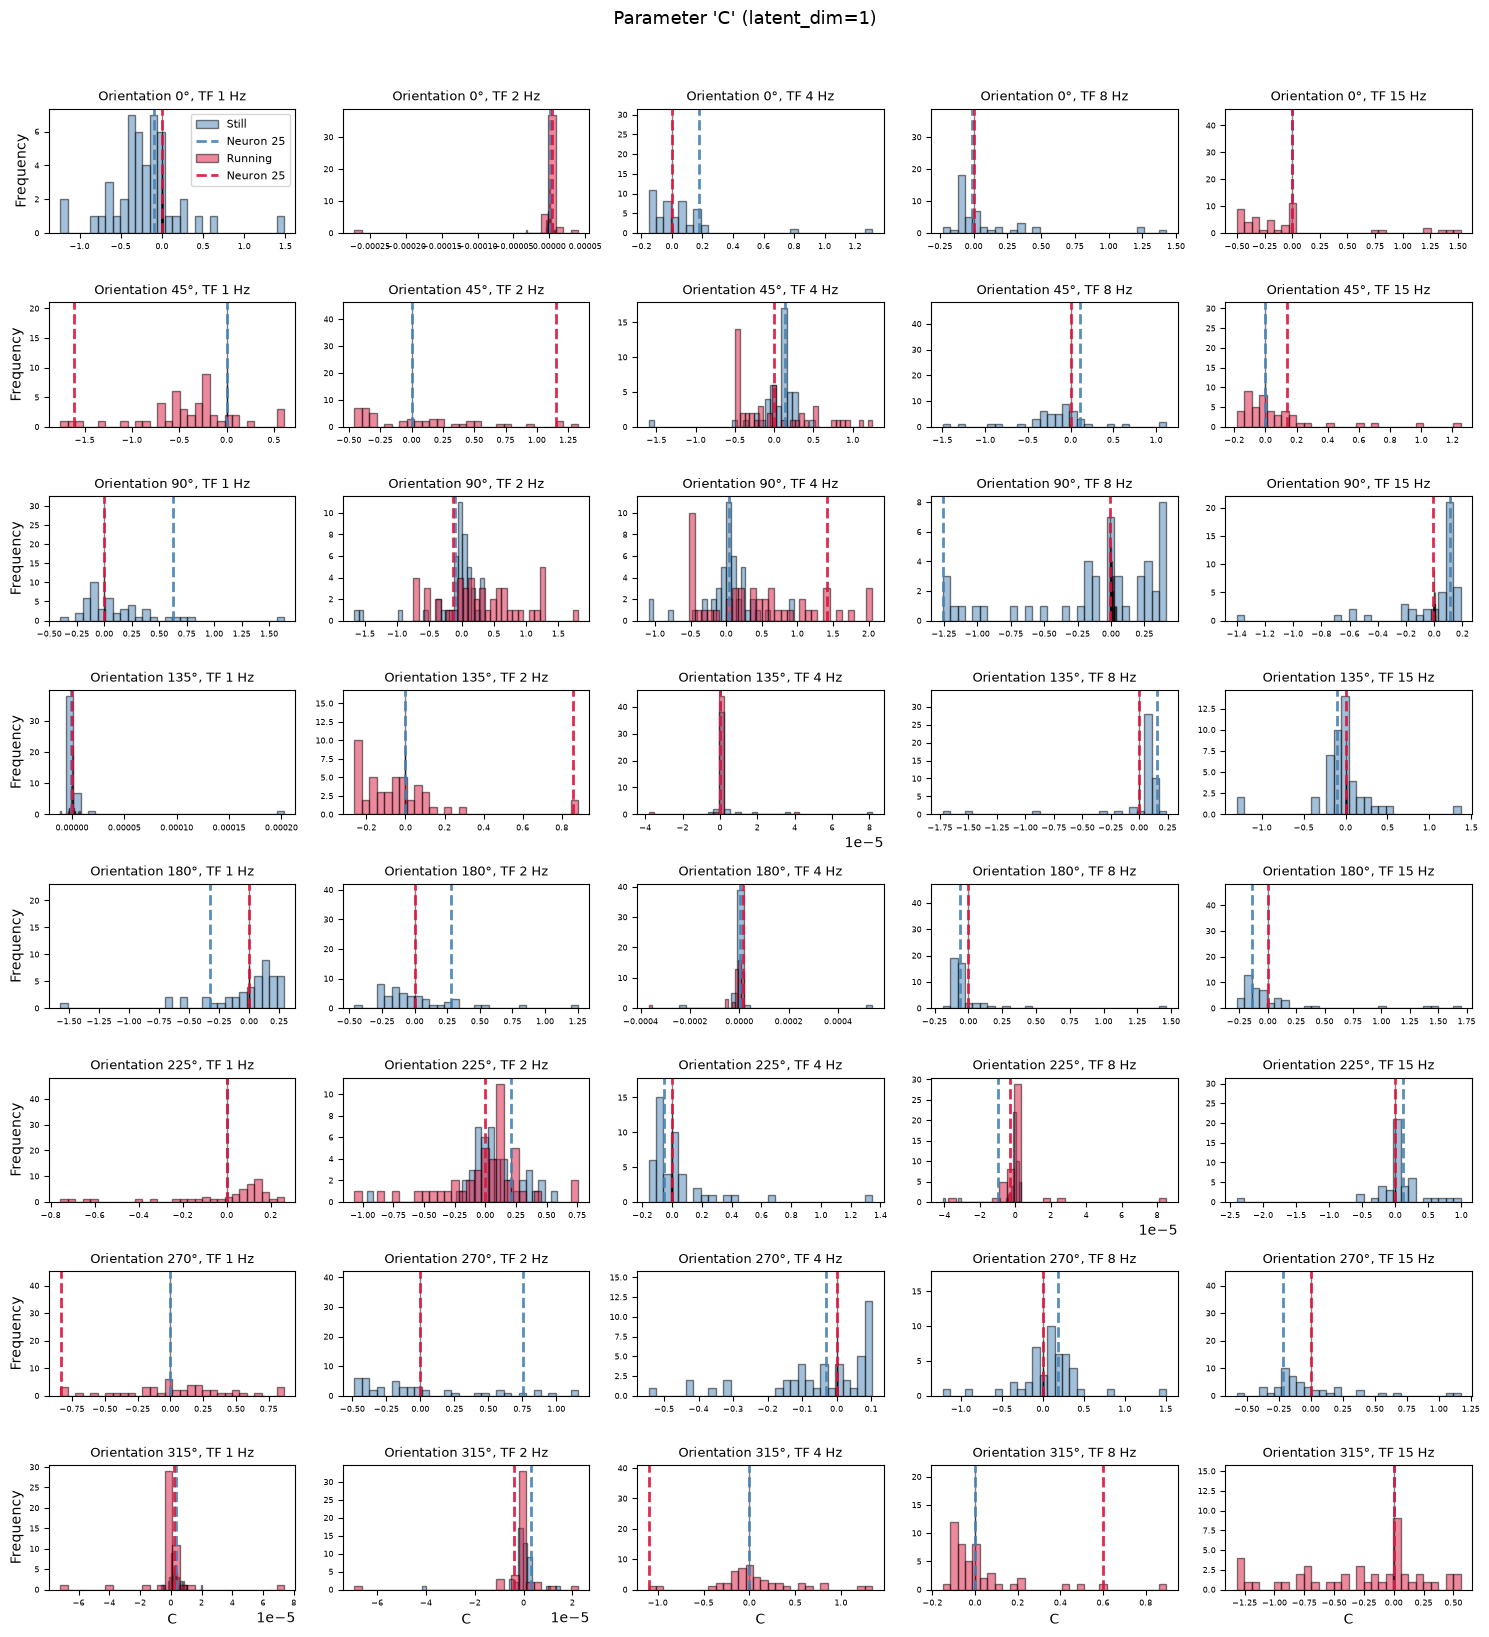

In [200]:
fig, axes = plot_param_histograms(fits, param_name="C", latent_dim=0, bins=30, neuron_idx=25)
plt.show()

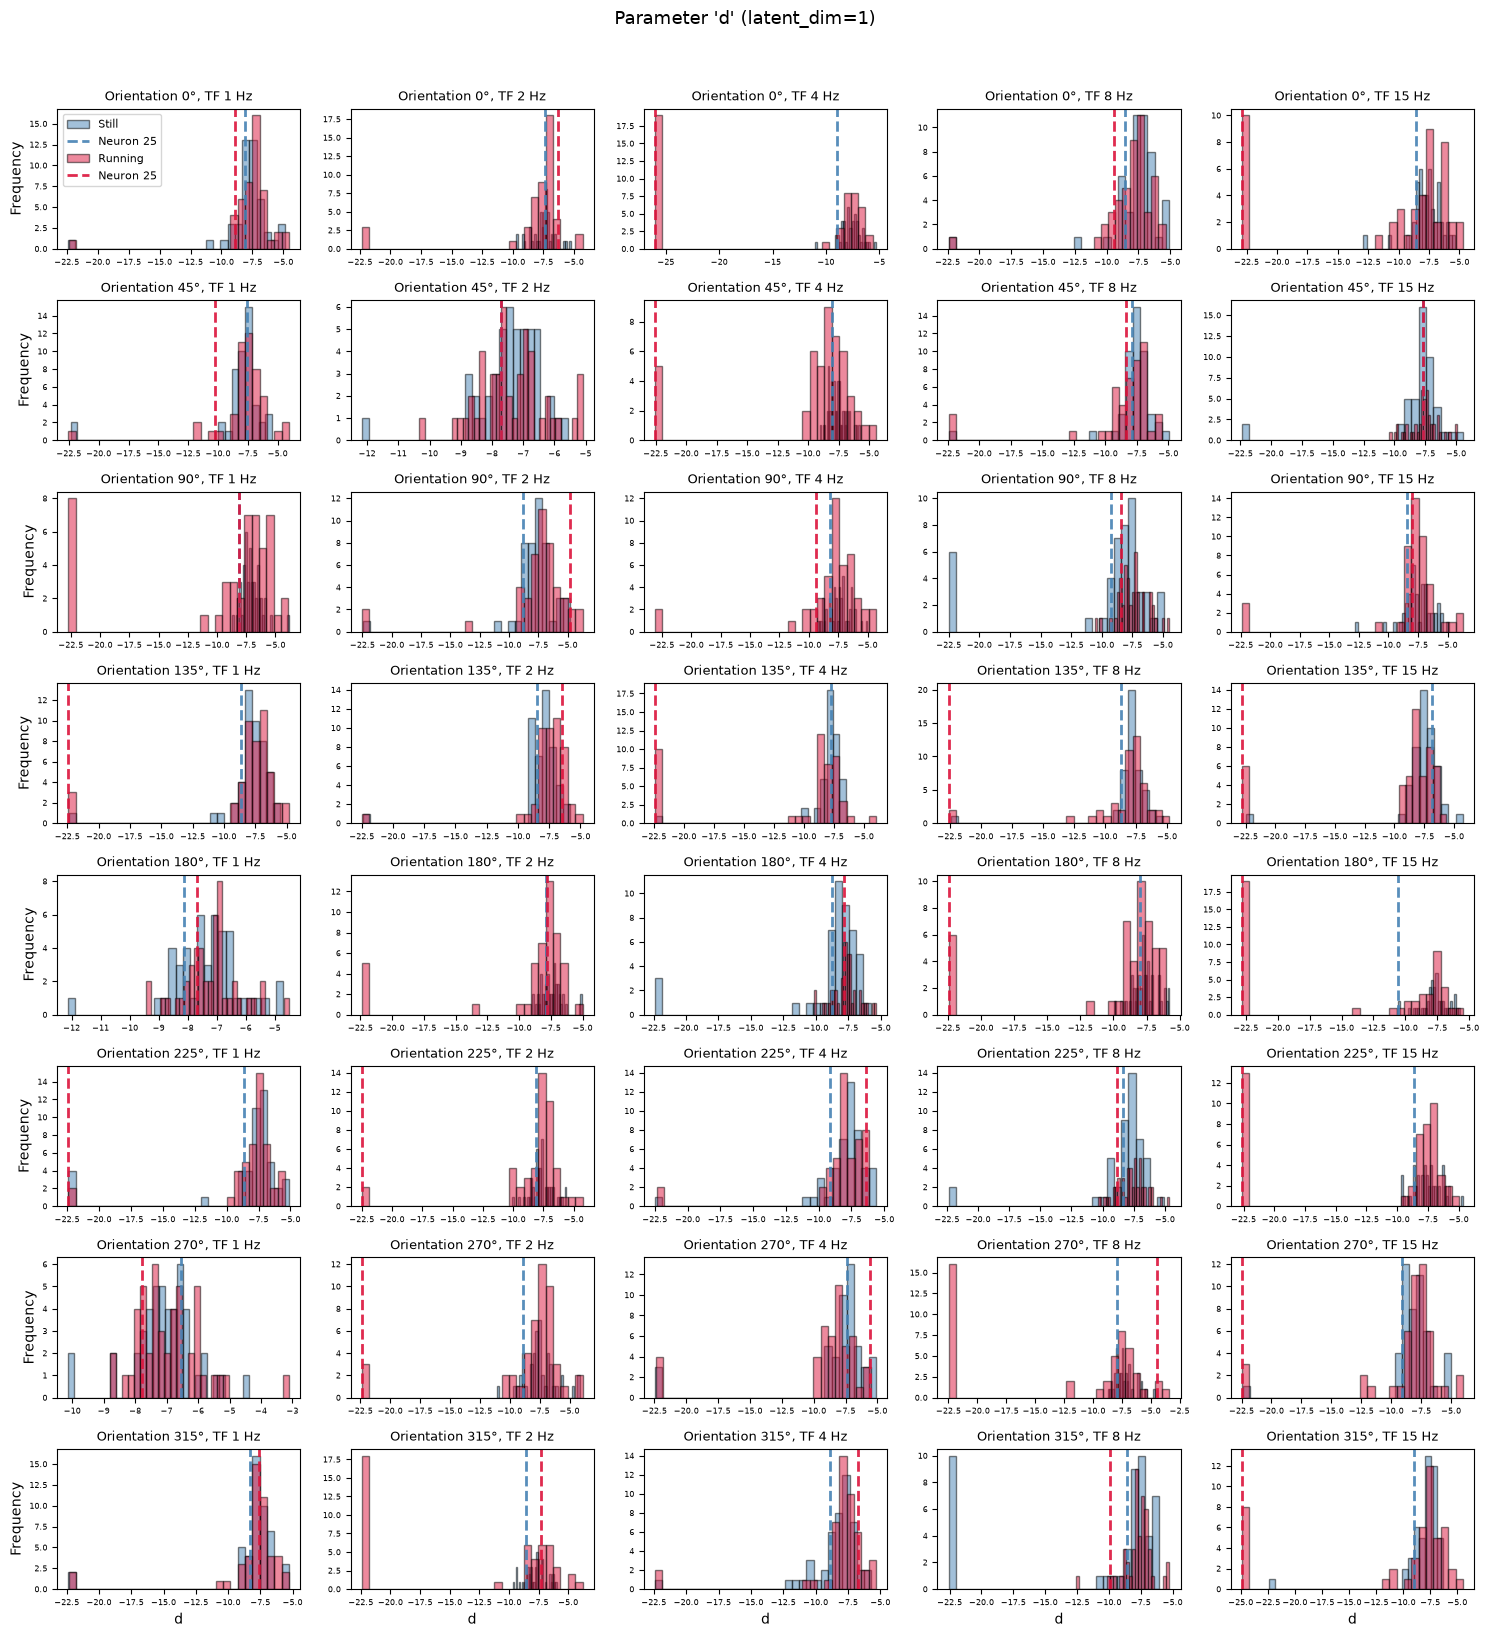

In [201]:
fig, axes = plot_param_histograms(fits, param_name="d", latent_dim=0, bins=30, neuron_idx=25)
plt.show()

Interestingly, in many conditions the neuron correlated most with running speed (neuron 25) is here an outlier in the baseline firing rate parameter (d) only for the running case. So maybe this neuron is especially high firing rate and thus correlates more with runnign speed? However, for parameter C (the parameter modeling the latent trace) we dont have significant deviation for neuron 25. 


## Compare latent trace with running speed

In [226]:
def plot_gpfa_latent_and_speed_grid(
    fits, 
    running_phase, 
    latent_dim=0,
    trial_idx=0, 
    figsize_per_cell=(3.5, 2)):
    """
    Plot one example trial's running speed and first-latent-dimension GPFA
    trajectory for every (orientation, temporal_frequency) condition, for a
    given running_phase.
    """
    color = "steelblue" if running_phase == 0 else "crimson"
    phase_label = "still" if running_phase == 0 else "running"

    keys = [k for k in fits.keys() if k[2] == running_phase]
    orientations = sorted({k[0] for k in keys})
    temporal_frequencies = sorted({k[1] for k in keys})

    fig, axes = plt.subplots(
        len(orientations), len(temporal_frequencies),
        figsize=(figsize_per_cell[0] * len(temporal_frequencies),
                 figsize_per_cell[1] * len(orientations)),
        squeeze=False,
    )

    for i, orientation in enumerate(orientations):
        for j, temporal_frequency in enumerate(temporal_frequencies):
            ax_speed = axes[i, j]
            fit_data = fits.get((orientation, temporal_frequency, running_phase))
            
            train_set, test_set, xval = fit_data
            fit = xval.fits[trial_idx]
            data = fit.experiment
            
            # plot running speed and latent trajectory for the first trial
            time = np.arange(data.T) * (data.binSize / 1000.0)

            ax_speed.plot(time, data.data[0]["running_speed"], color=color, label="Running Speed")
            if i == 0 and j == 0:
                ax_speed.set_ylabel("Running speed", color=color)
            ax_speed.tick_params(axis="y", labelcolor=color)

            ax_latent = ax_speed.twinx()
            latent = fit.infRes["post_mean"][0][latent_dim]
            ax_latent.plot(time, latent, color="orange", linestyle="--", label=f"Latent dim {latent_dim}")
            if i == 0 and j == 0:
                ax_latent.set_ylabel("Latent state", color="orange")
            ax_latent.tick_params(axis="y", labelcolor="orange")
            
            ax_speed.set_title(f"Orientation {orientation:g}°, TF {temporal_frequency:g} Hz", fontsize=9)

    for ax in axes[-1, :]:
        ax.set_xlabel("Time (s)")

    fig.suptitle(f"Movement: {phase_label}, latent dim {latent_dim}", fontsize=13, y=1.01)
    fig.tight_layout()
    return fig, axes

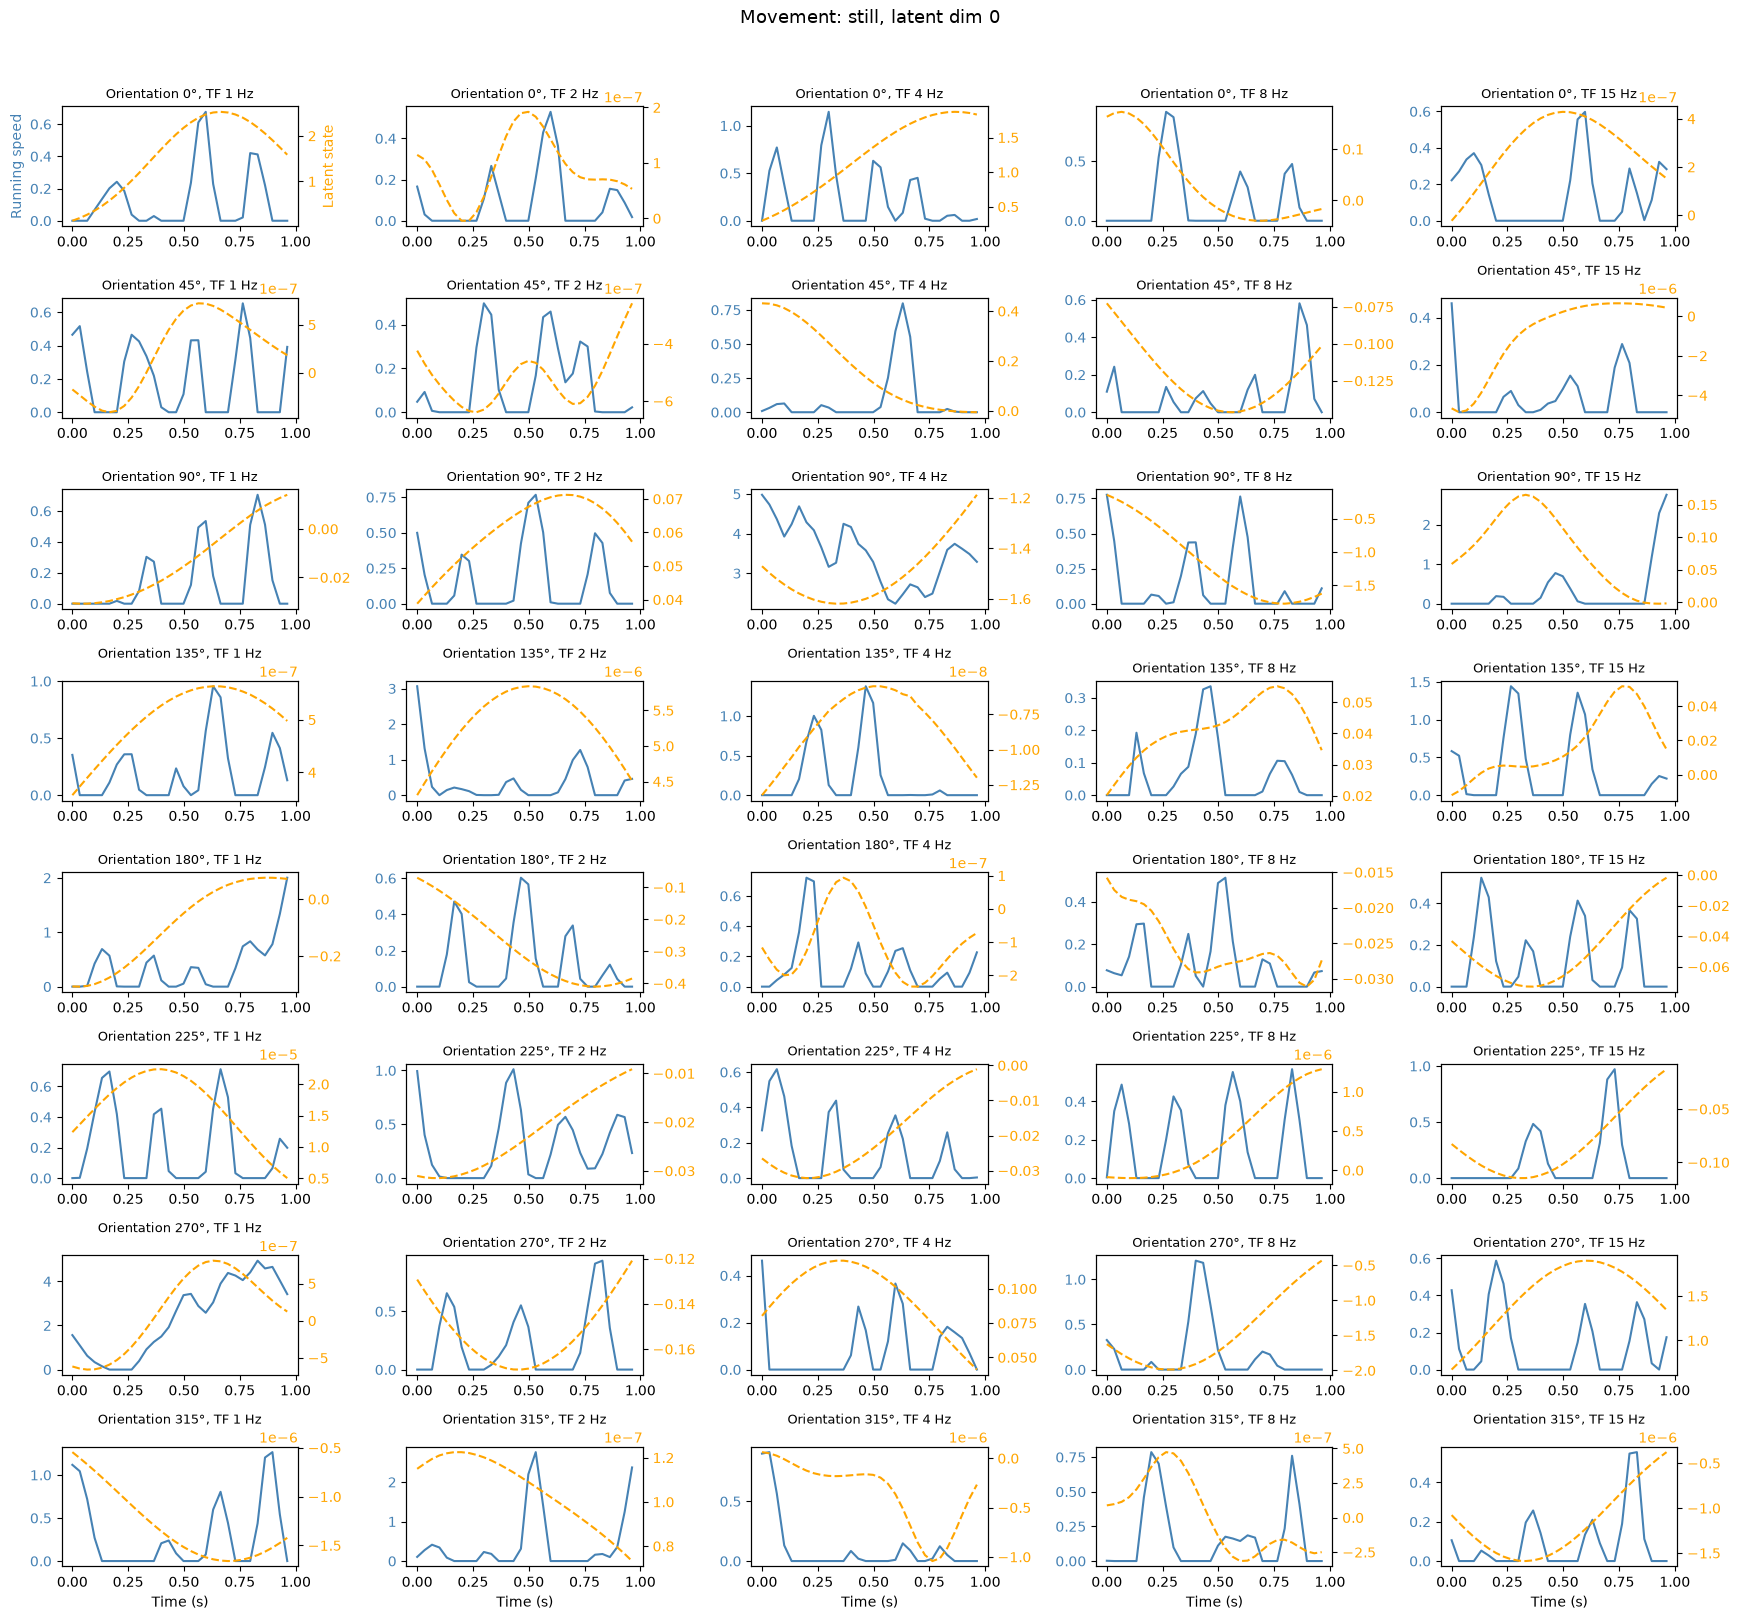

In [227]:
fig, axes = plot_gpfa_latent_and_speed_grid(fits, running_phase=0, latent_dim=0, trial_idx=0)
plt.show()

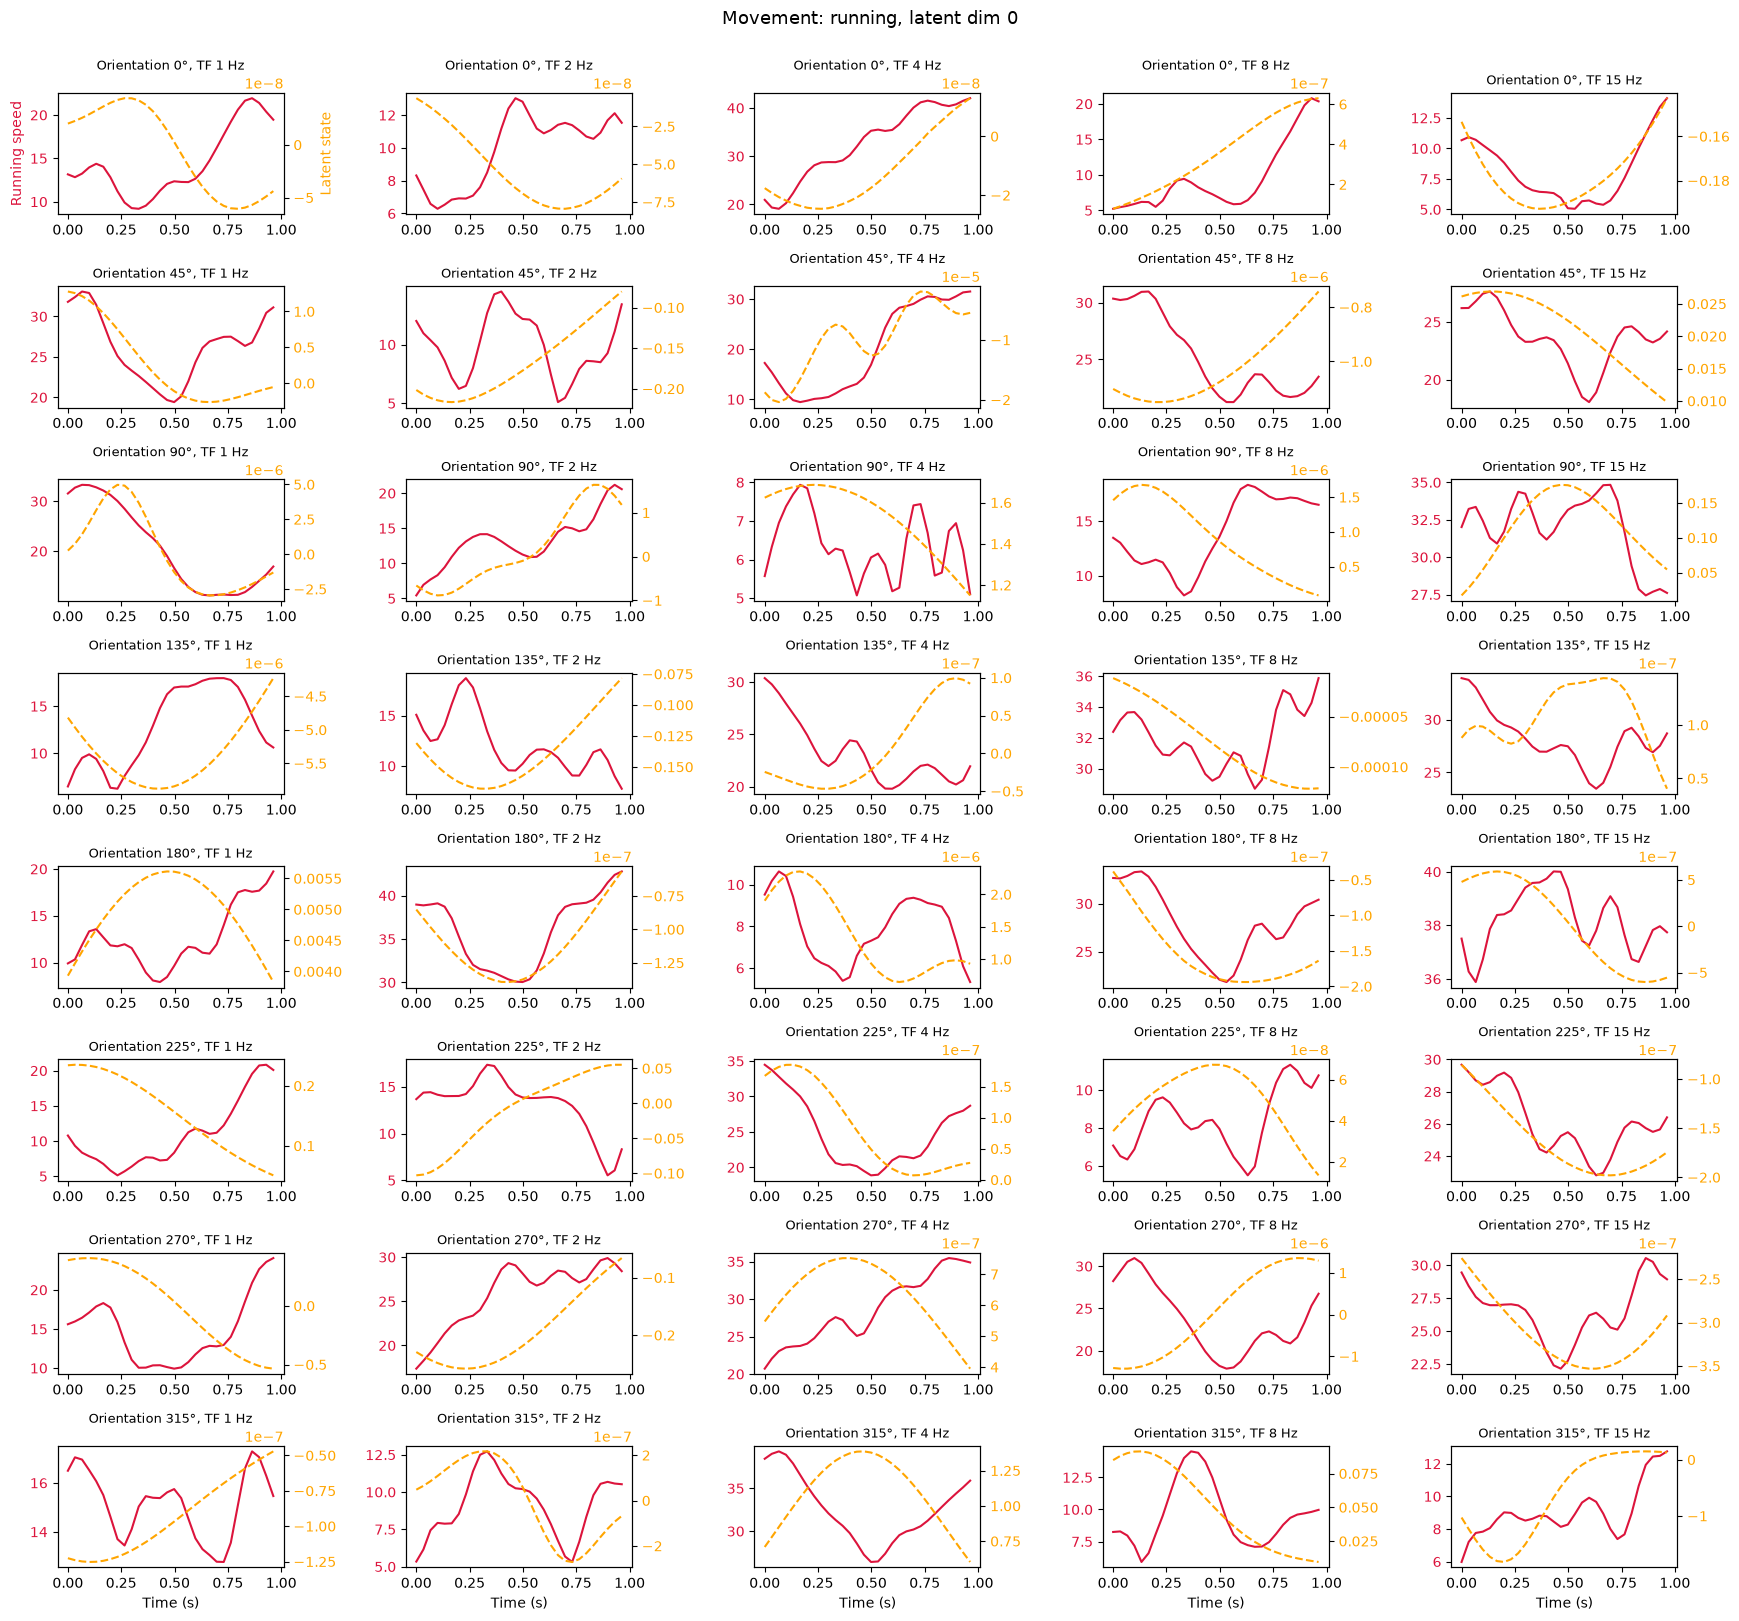

In [230]:
fig, axes = plot_gpfa_latent_and_speed_grid(fits, running_phase=1, latent_dim=0, trial_idx=1)
plt.show()